# Is a signal's link to points identity or state?

**Is a stat's tie to points about _who the player is_ (→ **own**), or _how he's doing right now_ (→ **time**)?**

_Read-only diagnostic — Rung 2, association only (no predictive claim)._
Population: `minutes > 0`, **DGW excluded**, per position, whole season, players with **≥ 10 games**.

This is the **per-signal** split. The points-only between/within split it sits against — how much weekly movement each position shows — lives in [`points_variance_ceiling.ipynb`](points_variance_ceiling.ipynb); read that first.

> **Classifier: CI-gated dominance.** `panel_class` is decided by the player-clustered bootstrap CI on the dominance contrast `|rho_between| − |rho_within|`: **identity_dominant** / **state_sensitive** when that CI clears 0, **mixed** when both axes are real but neither dominates, else an abstention (**indeterminate** / **undecomposable** / **insufficient_support**). The old `within_share` ratio (structurally biased — `rho_between` never entered it) is retained as a descriptive column only and no longer classifies.

## Setup & how to read

**Plain:** keep the weeks a player actually featured, drop double-gameweeks, treat each position separately. For each stat we ask whether its link to points comes from *good players* or *hot weeks* — and we only call it when the evidence is clear; otherwise we say **"can't tell"**.

> *In data terms:* leading-indicator universe (exact composites dropped); per-(signal, position) split via `bootstrap_panel_decomposition` (player-clustered bootstrap, B=1000, 95% CI, seed=0); class is CI-gated; pooled significance FDR-controlled (`benjamini_hochberg`); Kendall tau-b as a ties cross-check. The points-only between/within split is computed separately in `points_variance_ceiling.ipynb`.

**Glossary**
- **rho (ρ)** — rank correlation: how well two things move together (−1…1).
- **CI** — confidence interval: the plausible range, not one point guess.
- **rho_between** — link from *who the player is* (season averages) → **own**.
- **rho_within** — link from *how he's doing* (his own good/bad weeks) → **time**.
- **within_share** — descriptive ratio |rho_within|/|rho_pooled| (structurally biased; shown for context, does **not** decide `panel_class`).
- **dominance** — |rho_between| − |rho_within|; its bootstrap CI is what decides `panel_class` (> 0 → identity, < 0 → state).
- **panel_class** — the verdict: `identity_dominant` / `mixed` / `state_sensitive`, or an abstention (`indeterminate` / `undecomposable` / `insufficient_support`).
- **FDR** — multiple-test correction; stops us chasing flukes across many stats at once.
- **tau-b** — Kendall correlation, robust to many tied zeros (a sensitivity cross-check).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.relevance import (
    compute_relevance, leading_indicator_signals, leading_alive_signals, POSITIONS,
)
from research.kernels.diagnostic.panel import bootstrap_panel_decomposition, split_between_within_player_rho
from research.kernels.hypothesis.multiplicity import benjamini_hochberg

POSITIONS = list(POSITIONS)
# CI-gated class -> marker colour; abstentions greyed so they are never read as a verdict.
CLASS_COLOURS = {
    "state_sensitive": "#2ca02c", "mixed": "#ff7f0e", "identity_dominant": "#1f77b4",
    "indeterminate": "#bdbdbd", "undecomposable": "#d9d9d9", "insufficient_support": "#f0f0f0",
}

try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f"Rebuilding mart ({type(err).__name__})...")
    run_pipeline(force=True)
    loaded = load_mart()

mart = loaded.mart
df = mart[mart["gw"].between(1, loaded.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()

leading = sorted(leading_indicator_signals(drop_exact_composites=True))
alive_by_pos = {}
for p in POSITIONS:
    rel = compute_relevance(df[df["position"] == p], signals=leading, group_cols=())
    alive_by_pos[p] = leading_alive_signals(rel)

print(f"Study range: GW 1 - {loaded.data_cutoff_gw} | minutes > 0 | DGW excluded | n = {len(df):,}")
for p in POSITIONS:
    print(f"  {p}: n={len(df[df.position == p]):>6,} | {len(alive_by_pos[p])} live signals")

Study range: GW 1 - 38 | minutes > 0 | DGW excluded | n = 11,190
  GK: n=   747 | 3 live signals
  DEF: n= 3,845 | 9 live signals
  MID: n= 5,208 | 9 live signals
  FWD: n= 1,390 | 9 live signals


## The split — each stat vs points

**Is a stat's link to points about _who the player is_ (own) or _how he's doing_ (time)?**

> **Plain:** split each stat's link into a *who-the-player-is* part (`rho_between` → **own**) and a *how-he's-doing* part (`rho_within` → **time**), each with error bars. We assign a verdict **only when the error bars earn it**, else we abstain.
>
> *In data terms:* `bootstrap_panel_decomposition` (B=1000, 95% CI, seed=0); `panel_class` CI-gated; `fdr_reject` = link survives BH-FDR across the screen; `class_kendall` re-runs the call under tau-b — disagreement means read that cell with caution.

In [2]:
# Player-clustered bootstrap of the between/within split (Spearman), CI-gated class.
# min_appearances=10 matches the Step-1 between/within partition so both steps share one player population.
split_rows = []
for p in POSITIONS:
    for sig in alive_by_pos[p]:
        boot = bootstrap_panel_decomposition(df, sig, "total_points", p, seed=0, min_appearances=10)
        # Tie-corrected cross-check: does the point classification flip under Kendall tau-b?
        tau_split = split_between_within_player_rho(df, sig, "total_points", p, method="kendall", min_appearances=10)
        split_rows.append({"position": p, "signal": sig, "class_kendall": tau_split["panel_class"], **boot})
split_tbl = pd.DataFrame(split_rows)

# BH-FDR across the screen, on the clustered bootstrap pooled p (supported cells only).
split_tbl["fdr_reject"] = False
split_tbl["q_value"] = np.nan
has_p = split_tbl["rho_pooled_p"].notna()
if has_p.any():
    fdr = benjamini_hochberg(split_tbl.loc[has_p, "rho_pooled_p"].to_numpy(), alpha=0.05)
    split_tbl.loc[has_p, "fdr_reject"] = fdr["reject"]
    split_tbl.loc[has_p, "q_value"] = fdr["q_value"]

split_tbl["kendall_agrees"] = split_tbl["panel_class"] == split_tbl["class_kendall"]
cols = ["position", "signal", "rho_pooled", "rho_pooled_ci", "within_share", "within_share_ci",
        "panel_class", "fdr_reject", "q_value", "class_kendall", "n_players"]
display(split_tbl[cols].sort_values(["position", "rho_pooled"], ascending=[True, False]).round(4))

,position,signal,rho_pooled,rho_pooled_ci,within_share,within_share_ci,panel_class,fdr_reject,q_value,class_kendall,n_players
6,DEF,influence,0.5618,"(0.5312, 0.5888)",0.914,"(0.8732, 0.9479)",identity_dominant,True,0.0021,identity_dominant,145
5,DEF,defensive_contribution,0.4464,"(0.4122, 0.4812)",0.873,"(0.8178, 0.9244)",mixed,True,0.0021,identity_dominant,145
3,DEF,clearances_blocks_interceptions,0.4293,"(0.394, 0.4648)",0.893,"(0.8273, 0.9516)",mixed,True,0.0021,identity_dominant,145
9,DEF,threat,0.2446,"(0.2083, 0.2794)",0.910,"(0.8, 1.023)",identity_dominant,True,0.0021,identity_dominant,145
7,DEF,recoveries,0.2209,"(0.1745, 0.261)",0.739,"(0.6342, 0.84)",identity_dominant,True,0.0021,identity_dominant,145
11,DEF,xg,0.2176,"(0.1816, 0.2539)",0.917,"(0.7767, 1.0432)",identity_dominant,True,0.0021,identity_dominant,145
8,DEF,tackles,0.1922,"(0.1583, 0.2256)",0.863,"(0.7561, 0.9655)",mixed,True,0.0021,identity_dominant,145
10,DEF,xa,0.1887,"(0.1497, 0.2258)",0.736,"(0.5922, 0.8932)",identity_dominant,True,0.0021,identity_dominant,145
4,DEF,creativity,0.1769,"(0.1368, 0.2163)",0.816,"(0.6767, 0.9676)",mixed,True,0.0021,identity_dominant,145
24,FWD,influence,0.7307,"(0.6772, 0.7794)",NaN,"(1.1284, 1.2483)",identity_dominant,True,0.0021,identity_dominant,51


**Read the table:** `panel_class` is the verdict — trust it only where `rho_pooled_ci` excludes 0 (a real link) **and** `fdr_reject` is True. Abstention rows (`indeterminate` / `undecomposable` / `insufficient_support`) mean the one-season evidence can't separate identity from state; expect many for GK/FWD. The dumbbell below plots the same cells — one row per signal with two dots: **blue = `rho_between` (identity → own)**, **green = `rho_within` (state → time)**, each with its 95% CI whisker. The connecting bar is coloured by `panel_class`. When the blue dot sits to the *right* of the green dot, identity dominates (own the player); a green dot further right would mean state (time the form).

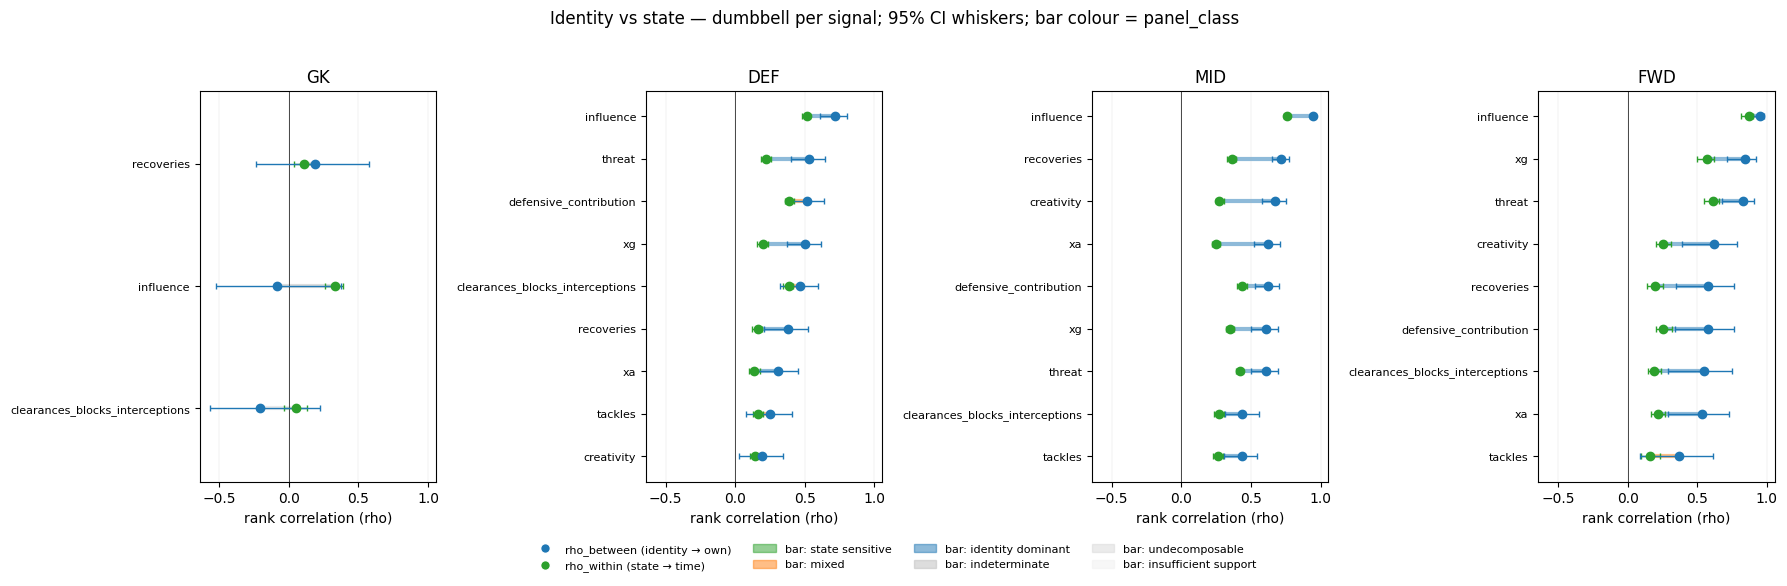

In [3]:
# Dumbbell plot: per signal, rho_between (identity) vs rho_within (state) with 95% CI whiskers.
# Signal names on the y-axis (no label collisions); the connecting bar is coloured by panel_class,
# so "identity wins" reads as the between-dot sitting to the right of the within-dot on every row.
BETWEEN_C, WITHIN_C = "#1f77b4", "#2ca02c"  # identity dot / state dot
fig, axes = plt.subplots(1, 4, figsize=(18, 5.2), sharex=True)
for ax, p in zip(axes, POSITIONS):
    pos_tbl = split_tbl[split_tbl.position == p].copy()
    pos_tbl = pos_tbl.sort_values("rho_between", ascending=True)  # strongest identity at top
    ylabels, ypos = [], []
    for y, (_, r) in enumerate(pos_tbl.iterrows()):
        ylabels.append(r["signal"])
        ypos.append(y)
        if pd.isna(r["rho_between"]) or pd.isna(r["rho_between_ci"][0]):
            ax.annotate("abstained (no support)", (0.02, y), fontsize=7, va="center", color="#bdbdbd")
            continue
        rho_b, rho_w = r["rho_between"], r["rho_within"]
        bar_c = CLASS_COLOURS.get(r["panel_class"], "#bdbdbd")
        # connecting bar coloured by the CI-gated class (grey = abstention)
        ax.plot([rho_w, rho_b], [y, y], color=bar_c, linewidth=3, alpha=0.5, zorder=1)
        # within (state) dot + CI
        xerr_w = [[max(0.0, rho_w - r["rho_within_ci"][0])], [max(0.0, r["rho_within_ci"][1] - rho_w)]]
        ax.errorbar(rho_w, y, xerr=xerr_w, fmt="o", ms=6, color=WITHIN_C,
                    ecolor=WITHIN_C, elinewidth=1.0, capsize=2, zorder=3)
        # between (identity) dot + CI
        xerr_b = [[max(0.0, rho_b - r["rho_between_ci"][0])], [max(0.0, r["rho_between_ci"][1] - rho_b)]]
        ax.errorbar(rho_b, y, xerr=xerr_b, fmt="o", ms=6, color=BETWEEN_C,
                    ecolor=BETWEEN_C, elinewidth=1.0, capsize=2, zorder=3)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_yticks(ypos)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_ylim(-0.6, len(ypos) - 0.4)
    ax.set_title(p)
    ax.set_xlabel("rank correlation (rho)")
    ax.grid(axis="x", linewidth=0.3, alpha=0.4)

# Legend: dot meanings + class colour of the connecting bar.
dot_legend = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=BETWEEN_C, ms=7, label="rho_between (identity → own)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=WITHIN_C, ms=7, label="rho_within (state → time)"),
]
bar_legend = [Patch(color=c, alpha=0.5, label=f"bar: {k.replace('_', ' ')}") for k, c in CLASS_COLOURS.items()]
fig.legend(handles=dot_legend + bar_legend, loc="lower center", ncol=4, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Identity vs state — dumbbell per signal; 95% CI whiskers; bar colour = panel_class", y=1.02)
plt.tight_layout()
plt.show()

## Summary — what to do per position

**Which stats are "own the player" vs "time his form" — and which we can't call on one season?**

> `own` = identity-dominant (re-ranks players you already rate); `time` = state-sensitive (worth acting on a current run); `own + time` = mixed. Abstentions are listed only as a count — they are *not* actionable. Single-season, descriptive — not a validated stable property (cross-season stability is a `families/` concern).

In [4]:
# Verdict generated from the table above — decided = a real, FDR-significant link with a clear class.
ROUTE = {"identity_dominant": "own", "state_sensitive": "time", "mixed": "own + time"}

print("IDENTITY vs STATE — per-position verdict (2025-26, single season, read-only)\n")
for p in POSITIONS:
    pos = split_tbl[split_tbl.position == p]
    decided = pos[pos.panel_class.isin(ROUTE) & pos.fdr_reject]
    print(f"{p}:  {len(decided)} of {len(pos)} stats decided, {len(pos) - len(decided)} abstained")
    for _, r in decided.sort_values("rho_pooled", ascending=False).iterrows():
        flag = "" if r.kendall_agrees else "  (tau-b disagrees — caution)"
        print(f"    {r.signal:<22} {r.panel_class:<18} -> {ROUTE[r.panel_class]:<11} rho={r.rho_pooled:.2f}{flag}")
    print()

print("Abstentions (indeterminate / undecomposable / insufficient_support) are the honest")
print("'can't tell on one season' answer — not a weak signal, just unproven here.")

IDENTITY vs STATE — per-position verdict (2025-26, single season, read-only)

GK:  0 of 3 stats decided, 3 abstained

DEF:  9 of 9 stats decided, 0 abstained
    influence              identity_dominant  -> own         rho=0.56
    defensive_contribution mixed              -> own + time  rho=0.45  (tau-b disagrees — caution)
    clearances_blocks_interceptions mixed              -> own + time  rho=0.43  (tau-b disagrees — caution)
    threat                 identity_dominant  -> own         rho=0.24
    recoveries             identity_dominant  -> own         rho=0.22
    xg                     identity_dominant  -> own         rho=0.22
    tackles                mixed              -> own + time  rho=0.19  (tau-b disagrees — caution)
    xa                     identity_dominant  -> own         rho=0.19
    creativity             mixed              -> own + time  rho=0.18  (tau-b disagrees — caution)

MID:  9 of 9 stats decided, 0 abstained
    influence              identity_dominant  